# Tilt census

A tilt-distance-specific census for anticyclonic (AE) and cyclonic (CE) eddies. The notebook retains the original mirrored-histogram idea but uses compact publication dashboards, smooth shading and embedded weighted box summaries.

Daily distributions give every eddy equal total weight, preventing long tracks from dominating. Per-eddy metrics contain one observation per eddy.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter
import seacofs_tilt_tools as tilt

AE_COLOUR = '#C44E52'
CE_COLOUR = '#2878A5'
TYPE_COLOURS = {'AE': AE_COLOUR, 'CE': CE_COLOUR}
PAGE_SIZE = (10, 7)
SAVE_FIGURES = False
FIGURE_DIR = Path('tilt_census_figures')
SMOOTH_SIGMA_BINS = 1.15
UPSTREAM_REGIONS = ['S1', 'U1', 'U2']
DOWNSTREAM_REGIONS = ['S2', 'D1', 'D2']
SUBREGION_ORDER = ['S1', 'U1', 'U2', 'S2', 'D1', 'D2']

mpl.rcParams.update({'figure.dpi':120,'savefig.dpi':600,'font.size':9.5,
 'axes.titlesize':10.5,'axes.labelsize':9.5,'legend.fontsize':8.5,
 'axes.spines.top':False,'axes.spines.right':False,'axes.linewidth':.8,
 'xtick.direction':'out','ytick.direction':'out','pdf.fonttype':42,'ps.fonttype':42})

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
df_eddies = df_eddies.sort_values(['Cyc','Eddy','Day']).copy()
region_group_map = {'S1':'Shelf','S2':'Shelf','U1':'Upstream','U2':'Upstream','D1':'Downstream','D2':'Downstream'}
sector_map = {**{r:'Upstream + S1' for r in UPSTREAM_REGIONS}, **{r:'Downstream + S2' for r in DOWNSTREAM_REGIONS}}
df_eddies['RegionGroup'] = df_eddies.Region.map(region_group_map)
df_eddies['Sector'] = df_eddies.Region.map(sector_map)
KEYS = ['Cyc','Eddy']
df_eddies['day_index'] = df_eddies.groupby(KEYS).cumcount()
last_index = df_eddies.groupby(KEYS).day_index.transform('max')
df_eddies['norm_time'] = np.where(last_index>0,df_eddies.day_index/last_index,np.nan)
df_eddies['lifetime_days'] = df_eddies.groupby(KEYS).Day.transform(lambda x:x.max()-x.min()+1)
tilt_data = df_eddies.dropna(subset=['TiltDis']).query("Cyc in ['AE','CE']").copy()
# Tilt distance and Rc are both in km, so this ratio is dimensionless.
valid_rc = np.isfinite(tilt_data['Rc']) & (tilt_data['Rc'] > 0)
tilt_data['tilt_over_Rc'] = np.where(valid_rc, tilt_data['TiltDis'] / tilt_data['Rc'], np.nan)
GLOBAL_TILT_LIMIT = float(tilt_data.TiltDis.quantile(.995))
GLOBAL_TILT_BINS = np.linspace(0,GLOBAL_TILT_LIMIT,43)
GLOBAL_TILT_RC_BINS = np.linspace(0,tilt_data.tilt_over_Rc.quantile(.995),43)
df_eddies.head()

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,Date,fname,TiltDis,TiltDir,Region,RegionGroup,Sector,day_index,norm_time,lifetime_days
26,2,1462,AE,151.793573,-37.940740,140,40,367.413413,196.922965,0.000038,...,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1,Downstream,Downstream + S2,0,0.000000,32
27,2,1463,AE,151.615529,-38.053390,136,36,356.354073,179.836500,0.000042,...,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1,Downstream,Downstream + S2,1,0.032258,32
28,2,1464,AE,151.505429,-38.086839,133,35,348.312905,173.055772,0.000041,...,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1,Downstream,Downstream + S2,2,0.064516,32
29,2,1465,AE,151.720810,-38.058377,139,37,365.294728,182.464807,0.000036,...,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,11.672594,226.828579,D1,Downstream,Downstream + S2,3,0.096774,32
30,2,1466,AE,151.590538,-38.149537,136,34,357.511090,169.056926,0.000035,...,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,12.557221,221.266550,D1,Downstream,Downstream + S2,4,0.129032,32


## Census summary
Counts remain available for documentation, while the figures below focus on tilt-distance results.

In [2]:
census = (df_eddies.groupby(['Cyc','Sector'],dropna=False)
          .agg(eddy_days=('Eddy','size'),unique_eddies=('Eddy','nunique'),
               tilt_days=('TiltDis','count'),median_tilt=('TiltDis','median')).reset_index())
display(census.round(2))
for cyc in ['AE','CE']:
    g=df_eddies[df_eddies.Cyc==cyc]; eligible=len(g)-6*g.Eddy.nunique()
    print(f'{cyc}: {g.Eddy.nunique():,} eddies; {g.TiltDis.notna().sum():,} tilt estimates; '
          f'{100*g.TiltDis.notna().sum()/eligible:.1f}% eligible-day success')

,Cyc,Sector,eddy_days,unique_eddies,tilt_days,median_tilt
0,AE,Downstream + S2,42584,960,35634,15.71
1,AE,Upstream + S1,22366,622,17973,29.38
2,AE,NaN,2,2,0,NaN
3,CE,Downstream + S2,35347,938,29459,12.03
4,CE,Upstream + S1,27127,729,22555,22.68


AE: 1,446 eddies; 53,607 tilt estimates; 95.3% eligible-day success
CE: 1,536 eddies; 52,014 tilt estimates; 97.7% eligible-day success


## Plotting and per-eddy summaries

In [3]:
def equal_eddy_weights(data):
    return 1.0/data.groupby(KEYS).Eddy.transform('size').astype(float)

def weighted_quantile(values,quantiles,weights=None):
    values=np.asarray(values,float); weights=np.ones(values.size) if weights is None else np.asarray(weights,float)
    ok=np.isfinite(values)&np.isfinite(weights)&(weights>0); values,weights=values[ok],weights[ok]
    if not values.size: return np.full(np.atleast_1d(quantiles).shape,np.nan)
    order=np.argsort(values); values,weights=values[order],weights[order]
    cdf=(np.cumsum(weights)-.5*weights)/weights.sum()
    return np.interp(np.atleast_1d(quantiles),cdf,values)

def gaussian_smooth(y,sigma=SMOOTH_SIGMA_BINS):
    radius=max(1,int(np.ceil(4*sigma))); x=np.arange(-radius,radius+1)
    kernel=np.exp(-.5*(x/sigma)**2); kernel/=kernel.sum()
    return np.convolve(y,kernel,mode='same')

def make_eddy_summary(data):
    rows=[]
    for (cyc,eddy),g in data.groupby(KEYS):
        x=g.TiltDis.dropna().to_numpy()
        if not len(x): continue
        ratio=g.tilt_over_Rc.dropna().to_numpy()
        rows.append({'Cyc':cyc,'Eddy':eddy,'mean_tilt':x.mean(),
          'mean_tilt_over_Rc':ratio.mean() if len(ratio) else np.nan,
          'min_tilt':x.min(),'max_tilt':x.max(),'tilt_range':np.ptp(x),
          'tilt_sd':np.std(x,ddof=1) if len(x)>1 else np.nan,'p90_tilt':np.quantile(x,.9),
          'n_tilt':len(x),'lifetime_days':g.lifetime_days.max()})
    return pd.DataFrame(rows)

def draw_weighted_box(ax,values,weights,y,colour,box_height):
    q05,q25,q50,q75,q95=weighted_quantile(values,[.05,.25,.5,.75,.95],weights)
    half_height=box_height/2
    ax.plot([q05,q95],[y,y],color=colour,lw=1.3,solid_capstyle='round',zorder=5)
    ax.plot([q05,q05],[y-.55*half_height,y+.55*half_height],color=colour,lw=1.1,zorder=5)
    ax.plot([q95,q95],[y-.55*half_height,y+.55*half_height],color=colour,lw=1.1,zorder=5)
    ax.add_patch(Rectangle((q25,y-half_height),q75-q25,box_height,facecolor='white',edgecolor=colour,alpha=.88,lw=1.3,zorder=6))
    ax.plot([q50,q50],[y-half_height,y+half_height],color=colour,lw=2.2,zorder=7)

def mirrored_density_box(ax,data,column,title,xlabel,*,daily=False,bins=None,xlim=None,show_legend=False):
    clean=data.dropna(subset=[column]).copy()
    if bins is None:
        values=clean[column].to_numpy(); hi=np.nanquantile(values,.995)
        bins=np.linspace(max(0,np.nanmin(values)),hi,38)
    centres=.5*(bins[:-1]+bins[1:]); stored={}; peak=0.0
    for cyc,sign in [('AE',1),('CE',-1)]:
        g=clean[clean.Cyc==cyc]; values=g[column].to_numpy()
        weights=equal_eddy_weights(g).to_numpy() if daily else np.ones(len(g))
        hist,_=np.histogram(values,bins=bins,weights=weights); hist=hist/hist.sum()*100 if hist.sum() else hist.astype(float)
        smooth=gaussian_smooth(hist); peak=max(peak,float(np.nanmax(smooth))); colour=TYPE_COLOURS[cyc]
        ax.fill_between(centres,0,sign*smooth,color=colour,alpha=.30,lw=0)
        ax.plot(centres,sign*smooth,color=colour,lw=1.8,label=cyc); stored[cyc]=(values,weights)
    ax.axhline(0,color='.25',lw=.7); ax.yaxis.set_major_formatter(FuncFormatter(lambda y,_:f'{abs(y):g}'))
    ax.set(title=title,xlabel=xlabel,ylabel='Probability (%)'); ax.grid(axis='x',alpha=.14,lw=.6)
    if xlim is not None: ax.set_xlim(xlim)
    box_offset=.30*peak; box_height=.12*peak
    draw_weighted_box(ax,*stored['AE'],box_offset,AE_COLOUR,box_height)
    draw_weighted_box(ax,*stored['CE'],-box_offset,CE_COLOUR,box_height)
    if show_legend: ax.legend(frameon=False,ncol=2,loc='lower right')

def draw_vertical_weighted_box(ax,values,weights,x,colour,box_width):
    q05,q25,q50,q75,q95=weighted_quantile(values,[.05,.25,.5,.75,.95],weights)
    half_width=box_width/2
    ax.plot([x,x],[q05,q95],color=colour,lw=1.3,solid_capstyle='round',zorder=5)
    ax.plot([x-.55*half_width,x+.55*half_width],[q05,q05],color=colour,lw=1.1,zorder=5)
    ax.plot([x-.55*half_width,x+.55*half_width],[q95,q95],color=colour,lw=1.1,zorder=5)
    ax.add_patch(Rectangle((x-half_width,q25),box_width,q75-q25,facecolor='white',edgecolor=colour,alpha=.88,lw=1.3,zorder=6))
    ax.plot([x-half_width,x+half_width],[q50,q50],color=colour,lw=2.2,zorder=7)

def vertical_split_violin_box(ax,groups,column,title,ylabel,*,daily=False,bins=None,show_legend=False):
    if bins is None:
        all_values=np.concatenate([g[column].dropna().to_numpy() for _,g in groups])
        bins=np.linspace(max(0,np.nanmin(all_values)),np.nanquantile(all_values,.995),38)
    centres=.5*(bins[:-1]+bins[1:]); curves={}; peak=0.0
    for group_index,(group_label,data) in enumerate(groups):
        for cyc in ['AE','CE']:
            g=data[data.Cyc==cyc].dropna(subset=[column]); values=g[column].to_numpy()
            weights=equal_eddy_weights(g).to_numpy() if daily else np.ones(len(g))
            hist,_=np.histogram(values,bins=bins,weights=weights)
            hist=hist/hist.sum()*100 if hist.sum() else hist.astype(float)
            smooth=gaussian_smooth(hist); peak=max(peak,float(np.nanmax(smooth)))
            curves[(group_index,cyc)]=(smooth,values,weights)
    half_violin_width=.55
    for group_index,(group_label,data) in enumerate(groups):
        for cyc,sign in [('AE',-1),('CE',1)]:
            smooth,values,weights=curves[(group_index,cyc)]
            width=half_violin_width*smooth/peak if peak>0 else smooth
            edge=group_index+sign*width; colour=TYPE_COLOURS[cyc]
            ax.fill_betweenx(centres,group_index,edge,color=colour,alpha=.30,lw=0)
            ax.plot(edge,centres,color=colour,lw=1.8)
            draw_vertical_weighted_box(ax,values,weights,group_index+sign*.13,colour,.10)
    ax.set_xlim(-.55,len(groups)-.45); ax.set_xticks(np.arange(len(groups)),[label for label,_ in groups])
    ax.set(title=title,ylabel=ylabel); ax.grid(axis='y',alpha=.14,lw=.6)
    if show_legend:
        handles=[Rectangle((0,0),1,1,facecolor=TYPE_COLOURS[cyc],alpha=.45,label=cyc) for cyc in ['AE','CE']]
        ax.legend(handles=handles,frameon=False,ncol=2,loc='upper right')

def panel_label(ax,label):
    ax.text(-.10,1.02,label+')',transform=ax.transAxes,fontweight='bold',fontsize=11)

def finish_figure(fig,name,title):
    fig.suptitle(title,fontsize=14,fontweight='bold',y=.997)
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(exist_ok=True); fig.savefig(FIGURE_DIR/f'{name}.pdf',bbox_inches='tight')
        fig.savefig(FIGURE_DIR/f'{name}.png',bbox_inches='tight',dpi=600)
    plt.show()

overall_eddy=make_eddy_summary(tilt_data)

## Figure 1 — Compact overall tilt census
Six magnitude summaries replace the original tall figure. Each inset shows the weighted 5th–95th percentile whisker, IQR and mean.

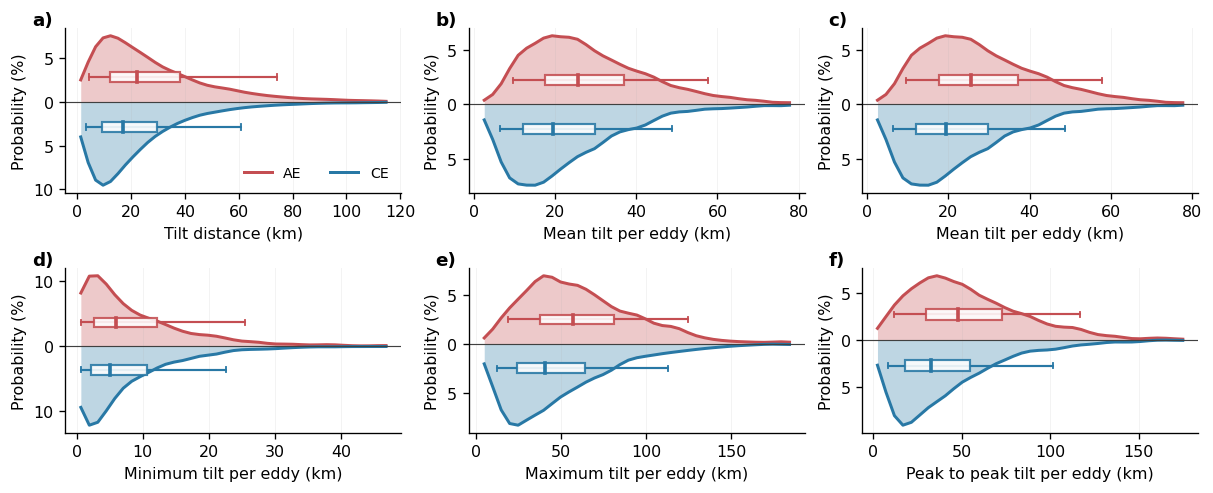

In [4]:
metrics=[
 ('TiltDis','','Tilt distance (km)',True,tilt_data),
 ('mean_tilt','','Mean tilt per eddy (km)',False,overall_eddy),
 ('mean_tilt','','Mean tilt per eddy (km)',False,overall_eddy),
 ('min_tilt','','Minimum tilt per eddy (km)',False,overall_eddy),
 ('max_tilt','','Maximum tilt per eddy (km)',False,overall_eddy),
 ('tilt_range','','Peak to peak tilt per eddy (km)',False,overall_eddy)]
fig,axes=plt.subplots(2,3,figsize=(10,4),constrained_layout=True)
for i,(ax,(column,title,xlabel,daily,source)) in enumerate(zip(axes.flat,metrics)):
    mirrored_density_box(ax,source,column,title,xlabel,daily=daily,bins=GLOBAL_TILT_BINS if daily else None,show_legend=i==0)
    panel_label(ax,chr(97+i))
# finish_figure(fig,'01_overall_tilt_census','Overall AE and CE tilt-distance census')

## Figure 2 — Upstream and downstream census
The upstream sector is S1 + U1 + U2; the downstream sector is S2 + D1 + D2. Daily tilt uses common bins.

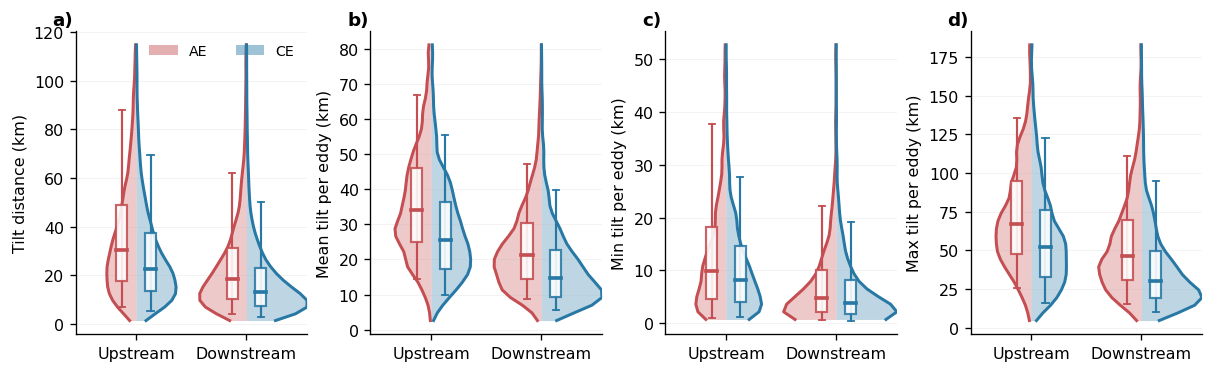

In [5]:
upstream_daily=tilt_data[tilt_data.Region.isin(UPSTREAM_REGIONS)].copy()
downstream_daily=tilt_data[tilt_data.Region.isin(DOWNSTREAM_REGIONS)].copy()
daily_groups=[('Upstream',upstream_daily),('Downstream',downstream_daily)]
eddy_groups=[('Upstream',make_eddy_summary(upstream_daily)),('Downstream',make_eddy_summary(downstream_daily))]
fig,axes=plt.subplots(1,4,figsize=(10,3),constrained_layout=True, sharey=False)
vertical_split_violin_box(axes[0],daily_groups,'TiltDis','','Tilt distance (km)',daily=True,bins=GLOBAL_TILT_BINS,show_legend=True)
vertical_split_violin_box(axes[1],eddy_groups,'mean_tilt','','Mean tilt per eddy (km)')
vertical_split_violin_box(axes[2],eddy_groups,'min_tilt','','Min tilt per eddy (km)')
vertical_split_violin_box(axes[3],eddy_groups,'max_tilt','','Max tilt per eddy (km)')
for i,ax in enumerate(axes): panel_label(ax,chr(97+i))
# finish_figure(fig,'02_upstream_downstream','Upstream–downstream contrast in AE and CE tilt distance')

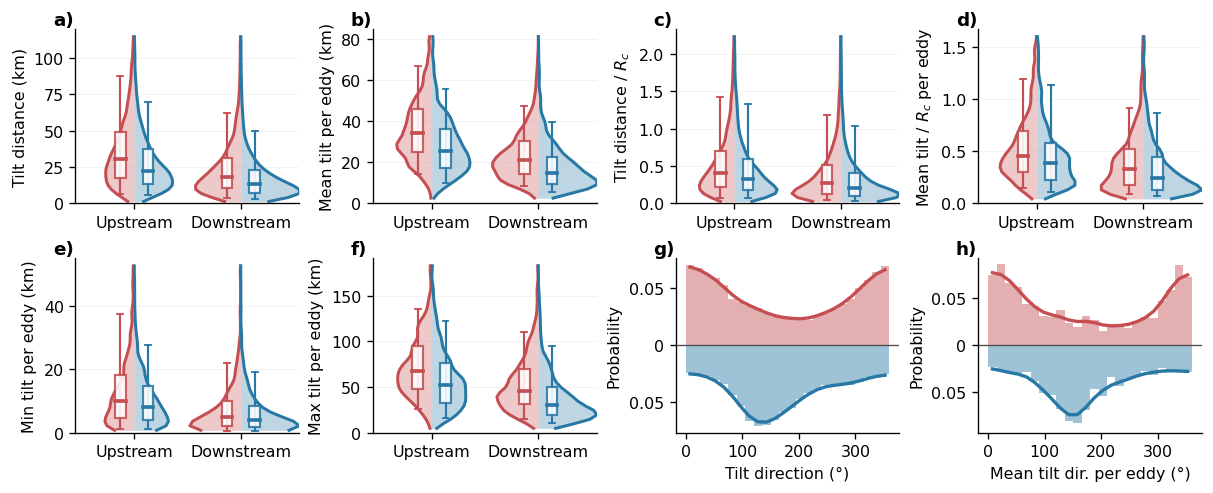

In [6]:
from matplotlib.ticker import FuncFormatter

upstream_daily=tilt_data[tilt_data.Region.isin(UPSTREAM_REGIONS)].copy()
downstream_daily=tilt_data[tilt_data.Region.isin(DOWNSTREAM_REGIONS)].copy()
daily_groups=[('Upstream',upstream_daily),('Downstream',downstream_daily)]
eddy_groups=[('Upstream',make_eddy_summary(upstream_daily)),('Downstream',make_eddy_summary(downstream_daily))]
fig,axes=plt.subplots(2,4,figsize=(10,4),constrained_layout=True, sharey=False)
vertical_split_violin_box(axes[0,0],daily_groups,'TiltDis','','Tilt distance (km)',daily=True,bins=GLOBAL_TILT_BINS,show_legend=False)
vertical_split_violin_box(axes[0,1],eddy_groups,'mean_tilt','','Mean tilt per eddy (km)')

vertical_split_violin_box(axes[0,2],daily_groups,'tilt_over_Rc','',r'Tilt distance / $R_c$',daily=True,bins=GLOBAL_TILT_RC_BINS)
vertical_split_violin_box(axes[0,3],eddy_groups,'mean_tilt_over_Rc','',r'Mean tilt / $R_c$ per eddy')

vertical_split_violin_box(axes[1,0],eddy_groups,'min_tilt','','Min tilt per eddy (km)')
vertical_split_violin_box(axes[1,1],eddy_groups,'max_tilt','','Max tilt per eddy (km)')

dir_bins = np.arange(0, 361, 15)
# Daily tilt direction
tilt.mirrored_hist(
    axes[1,2],
    tilt_data.loc[tilt_data.Cyc == 'AE', 'TiltDir'],
    tilt_data.loc[tilt_data.Cyc == 'CE', 'TiltDir'],
    dir_bins,
    'Tilt direction (°)',
    normalize=True,
    colors=(AE_COLOUR, CE_COLOUR)
)

# Circular mean direction for each eddy
eddy_dir = (
    tilt_data.dropna(subset=['TiltDir'])
    .assign(sin=np.sin(np.deg2rad(tilt_data.TiltDir)),
            cos=np.cos(np.deg2rad(tilt_data.TiltDir)))
    .groupby(['Cyc', 'Eddy'])[['sin', 'cos']].mean()
    .reset_index()
)

eddy_dir['mean_dir'] = (
    np.rad2deg(np.arctan2(eddy_dir.sin, eddy_dir.cos)) % 360
)

tilt.mirrored_hist(
    axes[1,3],
    eddy_dir.loc[eddy_dir.Cyc == 'AE', 'mean_dir'],
    eddy_dir.loc[eddy_dir.Cyc == 'CE', 'mean_dir'],
    dir_bins,
    'Mean tilt dir. per eddy (°)',
    normalize=True,
    colors=(AE_COLOUR, CE_COLOUR)
)

axes[1,2].yaxis.set_major_formatter(FuncFormatter(lambda y,_: f'{abs(y):g}'))
axes[1,3].yaxis.set_major_formatter(FuncFormatter(lambda y,_: f'{abs(y):g}'))

for i, ax in enumerate(axes.flatten()): 
    panel_label(ax,chr(97+i))
    if i<6: ax.set_ylim(0, None)

### Paper tilt statistics

In [12]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown


def tilt_census_report(
    df,
    first_last_days=3,
    upstream=("S1", "U1", "U2"),
    downstream=("S2", "D1", "D2"),
):
    keys = ["Cyc", "Eddy"]

    d = (
        df[df["Cyc"].isin(["AE", "CE"])]
        .sort_values(keys + ["Day"])
        .copy()
    )

    # Explicit Delta-method eligibility.
    d["track_index"] = d.groupby(keys).cumcount()
    d["track_length"] = d.groupby(keys)["Day"].transform("size")
    d["tilt_possible"] = (
        (d["track_index"] >= first_last_days)
        & (d["track_index"] < d["track_length"] - first_last_days)
    )
    d["valid_tilt"] = d["TiltDis"].notna()

    # Dimensionless daily tilt relative to surface radius.
    valid_rc = np.isfinite(d["Rc"]) & (d["Rc"] > 0)
    d["tilt_over_Rc"] = np.where(
        valid_rc,
        d["TiltDis"] / d["Rc"],
        np.nan,
    )

    d["Sector"] = pd.NA
    d.loc[d["Region"].isin(upstream), "Sector"] = "Upstream + S1"
    d.loc[d["Region"].isin(downstream), "Sector"] = "Downstream + S2"

    valid = d[d["valid_tilt"]].copy()

    # Dataset census.
    census_rows = []
    for cyc in ["All", "AE", "CE"]:
        g = d if cyc == "All" else d[d["Cyc"] == cyc]

        possible = int(g["tilt_possible"].sum())
        valid_possible = int(
            (g["valid_tilt"] & g["tilt_possible"]).sum()
        )

        census_rows.append({
            "Cyc": cyc,
            "unique_eddies": g[keys].drop_duplicates().shape[0],
            "eddy_days": len(g),
            "possible_tilt_days": possible,
            "valid_tilt_days": int(g["valid_tilt"].sum()),
            "raw_coverage_percent":
                100 * g["valid_tilt"].mean(),
            "possible_coverage_percent":
                100 * valid_possible / possible
                if possible else np.nan,
        })

    census = pd.DataFrame(census_rows).set_index("Cyc")

    # Daily tilt statistics.
    daily_rows = []
    for cyc in ["All", "AE", "CE"]:
        g = valid if cyc == "All" else valid[valid["Cyc"] == cyc]
        x = g["TiltDis"].dropna()
        r = g["tilt_over_Rc"].dropna()

        counts, edges = np.histogram(
            x,
            bins=np.arange(0, max(205, x.max() + 5), 5),
        )
        peak = np.argmax(counts)

        daily_rows.append({
            "Cyc": cyc,
            "n": len(x),
            "mean_km": x.mean(),
            "median_km": x.median(),
            "q25_km": x.quantile(.25),
            "q75_km": x.quantile(.75),
            "q90_km": x.quantile(.90),
            "q95_km": x.quantile(.95),
            "q99_km": x.quantile(.99),
            "maximum_km": x.max(),
            "modal_5km_interval":
                f"{edges[peak]:.0f}–{edges[peak + 1]:.0f}",
            "percent_gt_10km": 100 * (x > 10).mean(),
            "percent_gt_20km": 100 * (x > 20).mean(),
            "percent_gt_50km": 100 * (x > 50).mean(),
            "percent_gt_100km": 100 * (x > 100).mean(),
            "median_tilt_over_Rc": r.median(),
            "percent_tilt_gt_Rc": 100 * (r > 1).mean(),
        })

    daily = pd.DataFrame(daily_rows).set_index("Cyc")

    # One row per eddy.
    eddy_rows = []
    for (cyc, eddy), g in valid.groupby(keys):
        x = g["TiltDis"].dropna()
        r = g["tilt_over_Rc"].dropna()

        eddy_rows.append({
            "Cyc": cyc,
            "Eddy": eddy,
            "n_tilt": len(x),
            "mean_tilt_km": x.mean(),
            "median_tilt_km": x.median(),
            "minimum_tilt_km": x.min(),
            "maximum_tilt_km": x.max(),
            "range_tilt_km": x.max() - x.min(),
            "mean_tilt_over_Rc":
                r.mean() if len(r) else np.nan,
        })

    eddies = pd.DataFrame(eddy_rows)

    eddy_summary = (
        eddies.groupby("Cyc")
        .agg(
            eddies=("Eddy", "size"),
            median_eddy_mean_km=("mean_tilt_km", "median"),
            median_eddy_median_km=("median_tilt_km", "median"),
            median_eddy_minimum_km=("minimum_tilt_km", "median"),
            median_eddy_maximum_km=("maximum_tilt_km", "median"),
            median_eddy_range_km=("range_tilt_km", "median"),
            median_mean_tilt_over_Rc=(
                "mean_tilt_over_Rc", "median"
            ),
            percent_min_below_10km=(
                "minimum_tilt_km",
                lambda x: 100 * (x < 10).mean(),
            ),
            percent_max_above_50km=(
                "maximum_tilt_km",
                lambda x: 100 * (x > 50).mean(),
            ),
            percent_max_above_100km=(
                "maximum_tilt_km",
                lambda x: 100 * (x > 100).mean(),
            ),
            percent_max_above_200km=(
                "maximum_tilt_km",
                lambda x: 100 * (x > 200).mean(),
            ),
            largest_eddy_maximum_km=(
                "maximum_tilt_km", "max"
            ),
        )
    )

    # Sector comparison.
    sector = (
        valid.dropna(subset=["Sector"])
        .groupby(["Cyc", "Sector"])
        .agg(
            tilt_estimates=("TiltDis", "size"),
            mean_tilt_km=("TiltDis", "mean"),
            median_tilt_km=("TiltDis", "median"),
            q25_tilt_km=(
                "TiltDis",
                lambda x: x.quantile(.25),
            ),
            q75_tilt_km=(
                "TiltDis",
                lambda x: x.quantile(.75),
            ),
            median_tilt_over_Rc=(
                "tilt_over_Rc", "median"
            ),
            percent_gt_50km=(
                "TiltDis",
                lambda x: 100 * (x > 50).mean(),
            ),
        )
    )

    # Exact latitude bands used in the manuscript.
    valid["LatitudeZone"] = "32–36°S"
    valid.loc[valid["lat"] > -32, "LatitudeZone"] = "North of 32°S"
    valid.loc[valid["lat"] < -36, "LatitudeZone"] = "South of 36°S"

    latitude = (
        valid.groupby(["Cyc", "LatitudeZone"])
        .agg(
            n=("TiltDis", "size"),
            mean_tilt_km=("TiltDis", "mean"),
            median_tilt_km=("TiltDis", "median"),
            q25_tilt_km=(
                "TiltDis",
                lambda x: x.quantile(.25),
            ),
            q75_tilt_km=(
                "TiltDis",
                lambda x: x.quantile(.75),
            ),
        )
    )

    # Short, directly copyable results.
    ae_c, ce_c, all_c = (
        census.loc["AE"],
        census.loc["CE"],
        census.loc["All"],
    )
    ae_d, ce_d, all_d = (
        daily.loc["AE"],
        daily.loc["CE"],
        daily.loc["All"],
    )
    ae_e, ce_e = eddy_summary.loc["AE"], eddy_summary.loc["CE"]

    sentences = [
        f"Total eddies: {all_c.unique_eddies:,.0f}.",
        f"AEs: {ae_c.unique_eddies:,.0f}; "
        f"CEs: {ce_c.unique_eddies:,.0f}.",

        f"Total eddy-days: {all_c.eddy_days:,.0f}.",
        f"AE-days: {ae_c.eddy_days:,.0f}; "
        f"CE-days: {ce_c.eddy_days:,.0f}.",

        f"Valid tilt estimates: "
        f"{all_c.valid_tilt_days:,.0f} "
        f"({all_c.raw_coverage_percent:.1f}% of all eddy-days).",

        f"Possible-estimate success: "
        f"{ae_c.possible_coverage_percent:.1f}% for AEs and "
        f"{ce_c.possible_coverage_percent:.1f}% for CEs.",

        f"Mean AE tilt distance: {ae_d.mean_km:.1f} km.",
        f"Mean CE tilt distance: {ce_d.mean_km:.1f} km.",

        f"Median AE tilt distance: {ae_d.median_km:.1f} km "
        f"(IQR {ae_d.q25_km:.1f}–{ae_d.q75_km:.1f} km).",

        f"Median CE tilt distance: {ce_d.median_km:.1f} km "
        f"(IQR {ce_d.q25_km:.1f}–{ce_d.q75_km:.1f} km).",

        f"Modal 5-km tilt interval: "
        f"{ae_d.modal_5km_interval} km for AEs and "
        f"{ce_d.modal_5km_interval} km for CEs.",

        f"Tilt exceeded 50 km on "
        f"{ae_d.percent_gt_50km:.1f}% of AE-days and "
        f"{ce_d.percent_gt_50km:.1f}% of CE-days.",

        f"Tilt exceeded 100 km on "
        f"{ae_d.percent_gt_100km:.1f}% of AE-days and "
        f"{ce_d.percent_gt_100km:.1f}% of CE-days.",

        f"Median tilt/Rc: {ae_d.median_tilt_over_Rc:.2f} for AEs "
        f"and {ce_d.median_tilt_over_Rc:.2f} for CEs.",

        f"Tilt exceeded one Rc on "
        f"{ae_d.percent_tilt_gt_Rc:.1f}% of AE-days and "
        f"{ce_d.percent_tilt_gt_Rc:.1f}% of CE-days.",

        f"Median per-eddy mean tilt: "
        f"{ae_e.median_eddy_mean_km:.1f} km for AEs and "
        f"{ce_e.median_eddy_mean_km:.1f} km for CEs.",

        f"At least one tilt above 50 km occurred in "
        f"{ae_e.percent_max_above_50km:.1f}% of AEs and "
        f"{ce_e.percent_max_above_50km:.1f}% of CEs.",

        f"At least one tilt above 100 km occurred in "
        f"{ae_e.percent_max_above_100km:.1f}% of AEs and "
        f"{ce_e.percent_max_above_100km:.1f}% of CEs.",
    ]

    paragraph = (
        f"Application of the Delta method produced "
        f"{all_c.valid_tilt_days:,.0f} valid tilt estimates, "
        f"corresponding to {all_c.raw_coverage_percent:.1f}% of all "
        f"eddy-days. The dataset contained "
        f"{all_c.unique_eddies:,.0f} unique eddies, comprising "
        f"{ae_c.unique_eddies:,.0f} anticyclonic eddies and "
        f"{ce_c.unique_eddies:,.0f} cyclonic eddies. Valid estimates "
        f"were obtained for {ae_c.valid_tilt_days:,.0f} AE-days and "
        f"{ce_c.valid_tilt_days:,.0f} CE-days, representing "
        f"{ae_c.possible_coverage_percent:.1f}% and "
        f"{ce_c.possible_coverage_percent:.1f}% of possible estimates, "
        f"respectively. Median tilt distances were "
        f"{ae_d.median_km:.1f} km for AEs and "
        f"{ce_d.median_km:.1f} km for CEs, with interquartile ranges "
        f"of {ae_d.q25_km:.1f}–{ae_d.q75_km:.1f} km and "
        f"{ce_d.q25_km:.1f}–{ce_d.q75_km:.1f} km, respectively. "
        f"Tilt exceeded 50 km on {ae_d.percent_gt_50km:.1f}% of "
        f"AE-days and {ce_d.percent_gt_50km:.1f}% of CE-days."
    )

    return {
        "data": d,
        "valid": valid,
        "eddies": eddies,
        "census": census,
        "daily": daily,
        "eddy_summary": eddy_summary,
        "sector": sector,
        "latitude": latitude,
        "sentences": sentences,
        "paragraph": paragraph,
    }

In [17]:
results = tilt_census_report(df_eddies)

display(results["census"].round(2))
display(results["daily"].round(2))
display(results["eddy_summary"].round(2))
display(results["sector"].round(2))
display(results["latitude"].round(2))

print("\nCOPYABLE RESULT SENTENCES\n")
print("\n".join(results["sentences"]))

print("\n\nCOPYABLE DRAFT PARAGRAPH\n")
display(Markdown(results["paragraph"]))

,unique_eddies,eddy_days,possible_tilt_days,valid_tilt_days,raw_coverage_percent,possible_coverage_percent
Cyc,,,,,,
All,2982,127426,109534,105621,82.89,96.43
AE,1446,64952,56276,53607,82.53,95.26
CE,1536,62474,53258,52014,83.26,97.66


,n,mean_km,median_km,q25_km,q75_km,q90_km,q95_km,q99_km,maximum_km,modal_5km_interval,percent_gt_10km,percent_gt_20km,percent_gt_50km,percent_gt_100km,median_tilt_over_Rc,percent_tilt_gt_Rc
Cyc,,,,,,,,,,,,,,,,
All,105621,23.87,17.66,9.53,31.57,50.39,65.16,100.29,266.95,5–10,73.45,44.48,10.18,1.01,0.23,6.26
AE,53607,26.08,19.61,10.49,34.75,54.74,70.21,106.14,266.95,5–10,76.63,49.11,12.40,1.29,0.25,6.65
CE,52014,21.58,16.01,8.71,28.30,45.33,59.30,91.97,202.39,5–10,70.18,39.71,7.90,0.72,0.22,5.87


,eddies,median_eddy_mean_km,median_eddy_median_km,median_eddy_minimum_km,median_eddy_maximum_km,median_eddy_range_km,median_mean_tilt_over_Rc,percent_min_below_10km,percent_max_above_50km,percent_max_above_100km,percent_max_above_200km,largest_eddy_maximum_km
Cyc,,,,,,,,,,,,
AE,1422,25.65,22.34,5.94,56.93,47.90,0.40,68.35,57.81,13.64,0.63,266.95
CE,1531,19.55,16.97,5.07,40.68,32.84,0.31,72.76,39.12,7.77,0.07,202.39


tilt_estimates  mean_tilt_km  median_tilt_km  \
Cyc Sector                                                          
AE  Downstream + S2           35634         21.19           15.71   
    Upstream + S1             17973         35.77           29.38   
CE  Downstream + S2           29459         16.49           12.03   
    Upstream + S1             22555         28.24           22.68   

                     q25_tilt_km  q75_tilt_km  median_tilt_over_Rc  \
Cyc Sector                                                           
AE  Downstream + S2         8.69        27.64                 0.20   
    Upstream + S1          17.23        47.25                 0.36   
CE  Downstream + S2         6.73        20.87                 0.17   
    Upstream + S1          13.52        37.26                 0.31   

                     percent_gt_50km  
Cyc Sector                            
AE  Downstream + S2             7.36  
    Upstream + S1              22.39  
CE  Downstream + S2             3.90  
    Upstream + S1              13.12

n  mean_tilt_km  median_tilt_km  q25_tilt_km  \
Cyc LatitudeZone                                                      
AE  32–36°S        16367         25.02           19.41        11.28   
    North of 32°S  14726         36.54           30.44        17.68   
    South of 36°S  22514         20.01           14.36         7.87   
CE  32–36°S        14393         18.72           13.60         7.98   
    North of 32°S  19965         29.02           23.45        14.04   
    South of 36°S  17656         15.51           11.48         6.22   

                   q75_tilt_km  
Cyc LatitudeZone                
AE  32–36°S              32.65  
    North of 32°S        48.55  
    South of 36°S        25.88  
CE  32–36°S              23.56  
    North of 32°S        38.18  
    South of 36°S        20.09


COPYABLE RESULT SENTENCES

Total eddies: 2,982.
AEs: 1,446; CEs: 1,536.
Total eddy-days: 127,426.
AE-days: 64,952; CE-days: 62,474.
Valid tilt estimates: 105,621 (82.9% of all eddy-days).
Possible-estimate success: 95.3% for AEs and 97.7% for CEs.
Mean AE tilt distance: 26.1 km.
Mean CE tilt distance: 21.6 km.
Median AE tilt distance: 19.6 km (IQR 10.5–34.8 km).
Median CE tilt distance: 16.0 km (IQR 8.7–28.3 km).
Modal 5-km tilt interval: 5–10 km for AEs and 5–10 km for CEs.
Tilt exceeded 50 km on 12.4% of AE-days and 7.9% of CE-days.
Tilt exceeded 100 km on 1.3% of AE-days and 0.7% of CE-days.
Median tilt/Rc: 0.25 for AEs and 0.22 for CEs.
Tilt exceeded one Rc on 6.6% of AE-days and 5.9% of CE-days.
Median per-eddy mean tilt: 25.7 km for AEs and 19.5 km for CEs.
At least one tilt above 50 km occurred in 57.8% of AEs and 39.1% of CEs.
At least one tilt above 100 km occurred in 13.6% of AEs and 7.8% of CEs.


COPYABLE DRAFT PARAGRAPH



Application of the Delta method produced 105,621 valid tilt estimates, corresponding to 82.9% of all eddy-days. The dataset contained 2,982 unique eddies, comprising 1,446 anticyclonic eddies and 1,536 cyclonic eddies. Valid estimates were obtained for 53,607 AE-days and 52,014 CE-days, representing 95.3% and 97.7% of possible estimates, respectively. Median tilt distances were 19.6 km for AEs and 16.0 km for CEs, with interquartile ranges of 10.5–34.8 km and 8.7–28.3 km, respectively. Tilt exceeded 50 km on 12.4% of AE-days and 7.9% of CE-days.